In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import mesa
import pandas as pd

from mesa.visualization import SolaraViz, make_plot_component, make_space_component


In [2]:
def update_expectation(expected_outcome, outcome, alpha):
    expected_outcome += alpha * (outcome - expected_outcome)
    return expected_outcome



class AdoptionAgent(mesa.Agent):
    """An agent with skill, and the ability to use collective intelligence."""

    def __init__(self, model):
        """initialize an AdoptionAgent instance.

        Args:
            model: A model instance
        """
        super().__init__(model)
        
        "Preset starting variables for the model:"
        self.skill = np.clip(np.random.normal(loc=0.5, scale=0.2), 0, 1)
        self.ability = 0
        self.wins = 1
        self.losses = 1
        self.aichoice = 0
        self.expected = 0.5
        self.outcome = 0
        self.luck = 0

        "Variables that can be changed between batches:"
        self.alpha = 0.3
        self.beta = 0.1
        self.boost = 0.10
        self.middle = 0.05
        self.scaler = 0.02
        


    def move(self):
        """move to a random neighboring cell."""
        possible_steps = self.model.grid.get_neighborhood(
            self.pos, moore=True, include_center=False
        )
        new_position = self.random.choice(possible_steps)
        self.model.grid.move_agent(self, new_position)

    def compete(self):
        """One agent picks another agent randomly and compares scores updating all info"""
        cellmates = self.model.grid.get_cell_list_contents([self.pos])
        if len(cellmates) > 1:
            other = self.random.choice(cellmates)


            self.aichoice = np.random.choice([0, 1], p=[1 - self.expected, self.expected])
            other.aichoice = np.random.choice([0, 1], p=[1 - other.expected, other.expected])

            self.luck = np.clip(np.random.normal(loc= self.middle , scale= self.scaler ), 0, 1)
            other.luck = np.clip(np.random.normal(loc= self.middle , scale= self.scaler ), 0, 1)

            self.ability = self.skill + self.aichoice * self.boost + self.luck
            other.ability = other.skill + other.aichoice * other.boost + other.luck
            self.skill = np.clip(self.skill + ((-1)**self.aichoice ) * self.beta, 0, 1)
            if self.ability > other.ability:
                self.wins += 1
                self.outcome = 1 * self.aichoice
                self.expected = update_expectation(self.expected, self.outcome, self.alpha)

            else:
                self.losses += 1
                self.outcome = 1 - self.aichoice
                self.expected = update_expectation(self.expected, self.outcome, self.alpha)




    def step(self):
        """do one step of the agent."""
        self.move()
        self.compete()


class AdoptionModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self,
                 alpha = 0.3,
                 beta = 0.2,
                 boost = 0.05,
                 middle = 0.03,
                 scaler = 0.02,
                 n=80,
                 width=10,
                 height=10,
                 seed=None):
        
        """Initialize a competition instance.

        Args:
            N: The number of agents.
            width: width of the grid.
            height: Height of the grid.
        """
        super().__init__(seed=seed)
        self.num_agents = n
        self.alpha = alpha
        self.beta = beta
        self.boost = boost
        self.middle = middle
        self.scaler = scaler
        self.grid = mesa.space.MultiGrid(width, height, True)

        # Create agents
        agents = AdoptionAgent.create_agents(model=self, n=n)
        # Create x and y positions for agents
        x = self.rng.integers(0, self.grid.width, size=(n,))
        y = self.rng.integers(0, self.grid.height, size=(n,))
        for a, i, j in zip(agents, x, y):
            # Add the agent to a random grid cell
            self.grid.place_agent(a, (i, j))

        self.datacollector = mesa.DataCollector(
            agent_reporters={
                "Skill": "skill",
                "Ability": "ability",
                "Wins": "wins",
                "Losses": "losses",
                "AI Usage Choice": "aichoice",
                "Expected": "expected",
                "Outcome": "outcome",
                "Luck" : "luck"
            }
        )
        self.datacollector.collect(self)

    def step(self):
        """do one step of the model"""
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

In [3]:
model = AdoptionModel(100)
for _ in range(200):
    model.step()


data = model.datacollector.get_agent_vars_dataframe()
# Use seaborn

data


Skill   Ability  Wins  Losses  AI Usage Choice  Expected  \
Step AgentID                                                                
0    1        0.381477  0.000000     1       1                0  0.500000   
     2        0.752828  0.000000     1       1                0  0.500000   
     3        0.544629  0.000000     1       1                0  0.500000   
     4        0.588662  0.000000     1       1                0  0.500000   
     5        0.568558  0.000000     1       1                0  0.500000   
...                ...       ...   ...     ...              ...       ...   
200  76       0.100000  0.059576    33      80                0  0.636259   
     77       0.100000  0.055096    31      92                0  0.159553   
     78       0.500000  0.451283    28      71                0  0.758291   
     79       0.100000  0.059132    25      80                0  0.499477   
     80       0.000000  0.133017    43      83                1  0.426224   

              Outcome      Luck  
Step AgentID                     
0    1              0  0.000000  
     2              0  0.000000  
     3              0  0.000000  
     4              0  0.000000  
     5              0  0.000000  
...               ...       ...  
200  76             1  0.059576  
     77             0  0.055096  
     78             1  0.051283  
     79             1  0.059132  
     80             0  0.033017  

[16080 rows x 8 columns]

In [4]:
update_expectation(, outcome, alpha)

SyntaxError: invalid syntax (1945143677.py, line 1)

In [5]:
params = {
          "boost": [0.0, 0.01, 0.2, 0.3, 0.4, 0.5],
          }

results = mesa.batch_run(
    AdoptionModel,
    parameters=params,
    iterations=1,
    max_steps=100,
    number_processes=1,
    data_collection_period=1,
    display_progress=True,
)


results_df = pd.DataFrame(results)
print(results_df.keys())

  0%|          | 0/6 [00:00<?, ?it/s]

Index(['RunId', 'iteration', 'Step', 'boost', 'AgentID', 'Skill', 'Ability',
       'Wins', 'Losses', 'AI Usage Choice', 'Expected', 'Outcome', 'Luck'],
      dtype='object')


In [6]:
data = results_df
data

,RunId,iteration,Step,boost,AgentID,Skill,Ability,Wins,Losses,AI Usage Choice,Expected,Outcome,Luck
0,0,0,0,0.0,1,0.395460,0.000000,1,1,0,0.500000,0,0.000000
1,0,0,0,0.0,2,0.457085,0.000000,1,1,0,0.500000,0,0.000000
2,0,0,0,0.0,3,0.370249,0.000000,1,1,0,0.500000,0,0.000000
3,0,0,0,0.0,4,0.511496,0.000000,1,1,0,0.500000,0,0.000000
4,0,0,0,0.0,5,0.402883,0.000000,1,1,0,0.500000,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48475,5,0,100,0.5,76,0.100000,0.331523,15,37,1,0.479734,0,0.031523
48476,5,0,100,0.5,77,0.600000,0.530444,15,48,0,0.765574,1,0.030444
48477,5,0,100,0.5,78,0.700000,0.989336,21,36,1,0.714752,1,0.089336
48478,5,0,100,0.5,79,0.000000,0.257176,11,45,1,0.510307,0,0.057176


In [7]:
RunId_dataset = [data[data['RunId'] == i] for i in range(6)]

data_0, data_1, data_2, data_3, data_4, data_5 = [data[data['RunId'] == i] for i in range(6)]

data_0

,RunId,iteration,Step,boost,AgentID,Skill,Ability,Wins,Losses,AI Usage Choice,Expected,Outcome,Luck
0,0,0,0,0.0,1,0.395460,0.000000,1,1,0,0.500000,0,0.000000
1,0,0,0,0.0,2,0.457085,0.000000,1,1,0,0.500000,0,0.000000
2,0,0,0,0.0,3,0.370249,0.000000,1,1,0,0.500000,0,0.000000
3,0,0,0,0.0,4,0.511496,0.000000,1,1,0,0.500000,0,0.000000
4,0,0,0,0.0,5,0.402883,0.000000,1,1,0,0.500000,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8075,0,0,100,0.0,76,0.228911,0.476184,15,31,1,0.875635,1,0.047273
8076,0,0,100,0.0,77,0.900000,1.145667,26,29,1,0.365728,0,0.045667
8077,0,0,100,0.0,78,0.000000,0.115873,5,45,1,0.474603,0,0.015873
8078,0,0,100,0.0,79,0.700000,0.713824,15,44,0,0.335211,0,0.013824


/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_58536/2863327706.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Step'] = pd.to_numeric(df['Step'])
/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_58536/2863327706.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AI Usage Choice'] = pd.to_numeric(df['AI Usage Choice'])
/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_58536/2863327706.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

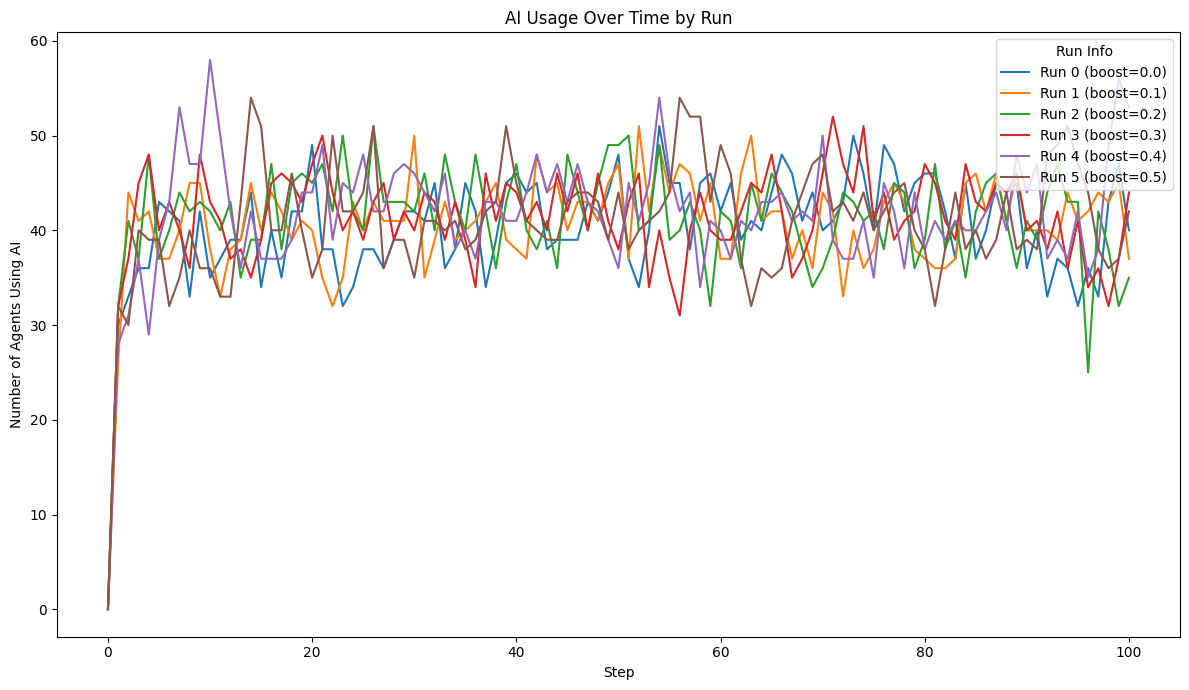

In [68]:

# Boost values for each RunId
boosts = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

# List of your dataframes
dataframes = [data_0, data_1, data_2, data_3, data_4, data_5]

plt.figure(figsize=(12, 7))

# Plot each line
for i, df in enumerate(dataframes):
    # Ensure 'Step' is numeric
    df['Step'] = pd.to_numeric(df['Step'])
    df['AI Usage Choice'] = pd.to_numeric(df['AI Usage Choice'])

    # Group by step and sum AI usage
    summed = df.groupby('Step')['AI Usage Choice'].sum().reset_index()

    # Plot the line
    sns.lineplot(data=summed, x='Step', y='AI Usage Choice', label=f'Run {i} (boost={boosts[i]})')

# Final touches
plt.title('AI Usage Over Time by Run')
plt.xlabel('Step')
plt.ylabel('Number of Agents Using AI')
plt.legend(title='Run Info', loc='upper right')
plt.tight_layout()
plt.show()

,RunId,iteration,Step,boost,AgentID,Skill,Ability,Wins,Losses,AI Usage Choice,Expected,Outcome,Luck
0,0,0,0,0.0,1,0.318375,0.000000,1,1,0,0.500000,0,0.000000
1,0,0,0,0.0,2,0.144462,0.000000,1,1,0,0.500000,0,0.000000
2,0,0,0,0.0,3,0.453004,0.000000,1,1,0,0.500000,0,0.000000
3,0,0,0,0.0,4,0.247728,0.000000,1,1,0,0.500000,0,0.000000
4,0,0,0,0.0,5,0.452662,0.000000,1,1,0,0.500000,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005,0,0,100,0.0,6,0.667092,0.736015,6,11,0,0.468639,0,0.118923
1006,0,0,100,0.0,7,0.101020,0.340758,2,9,1,0.431197,0,0.089738
1007,0,0,100,0.0,8,0.690453,0.797576,3,3,0,0.428050,1,0.107123
1008,0,0,100,0.0,9,0.838602,1.097862,7,10,1,0.596436,1,0.109260


/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_50867/4191016953.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Step'] = pd.to_numeric(df['Step'])
/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_50867/4191016953.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AI Usage Choice'] = pd.to_numeric(df['AI Usage Choice'])
/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_50867/4191016953.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

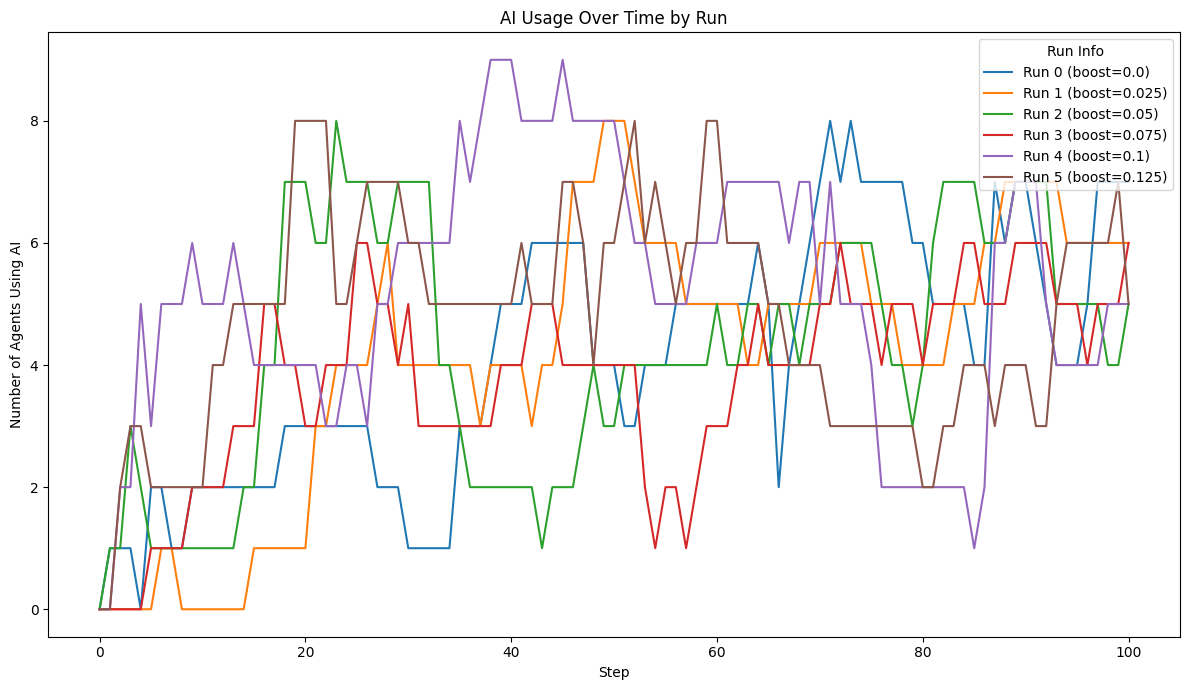

In [51]:

# Boost values for each RunId
boosts = [0.0, 0.025, 0.05, 0.075, 0.1, 0.125]

# List of your dataframes
dataframes = [data_0, data_1, data_2, data_3, data_4, data_5]

# Set up the plot
plt.figure(figsize=(12, 7))

# Plot each line
for i, df in enumerate(dataframes):
    # Ensure 'Step' is numeric
    df['Step'] = pd.to_numeric(df['Step'])
    df['AI Usage Choice'] = pd.to_numeric(df['AI Usage Choice'])

    # Group by step and sum AI usage
    summed = df.groupby('Step')['AI Usage Choice'].sum().reset_index()

    # Plot the line
    sns.lineplot(data=summed, x='Step', y='AI Usage Choice', label=f'Run {i} (boost={boosts[i]})')

# Final touches
plt.title('AI Usage Over Time by Run')
plt.xlabel('Step')
plt.ylabel('Number of Agents Using AI')
plt.legend(title='Run Info', loc='upper right')
plt.tight_layout()
plt.show()

In [41]:
data

,RunId,iteration,Step,boost,AgentID,Skill,Ability,Wins,Losses,AI Usage Choice,Expected,Outcome,Luck
0,0,0,0,0.000,1,0.632983,0.000000,1,1,0,0.500000,0,0.000000
1,0,0,0,0.000,2,0.096942,0.000000,1,1,0,0.500000,0,0.000000
2,0,0,0,0.000,3,0.612177,0.000000,1,1,0,0.500000,0,0.000000
3,0,0,0,0.000,4,0.435746,0.000000,1,1,0,0.500000,0,0.000000
4,0,0,0,0.000,5,0.390463,0.000000,1,1,0,0.500000,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6055,5,0,100,0.125,6,0.894464,1.120422,6,7,1,0.477831,0,0.075958
6056,5,0,100,0.125,7,0.628857,0.653125,4,5,0,0.595242,0,0.074268
6057,5,0,100,0.125,8,0.475999,0.714664,2,4,1,0.490950,0,0.088664
6058,5,0,100,0.125,9,0.587190,0.693762,3,4,0,0.433755,0,0.106573


In [ ]:
sns.scatterplot(data=data, x='Wins', y='Losses', hue='AI Usage Choice', palette='viridis')

In [ ]:
plt.figure(figsize=(10, 6))

# Loop through each runId from 0 to 5 and plot the line
for run_id in range(6):
    run_data = data[data['RunId'] == run_id]
    sns.lineplot(x='Step', y='boost', data=run_data, label=f'Run {run_id}')

plt.title('Boost per Step for Each Run')
plt.xlabel('Step')
plt.ylabel('Boost')
plt.legend(title='RunId')
plt.grid(True)
plt.tight_layout()
plt.show()

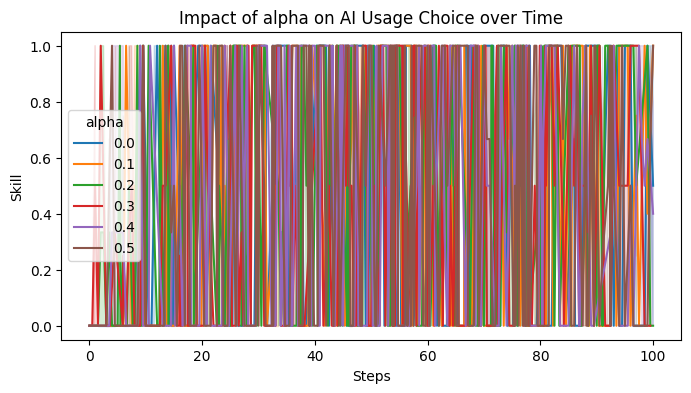

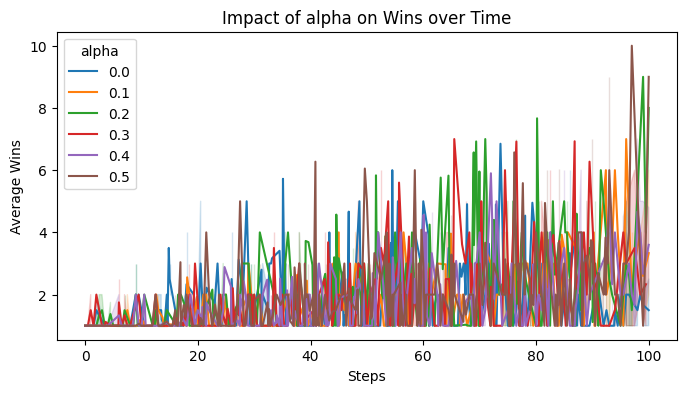

In [23]:
g = sns.lineplot(
    data=agg_results_df, 
    x="Step", 
    y="Wins",  # Plotting Wins over time
    hue="alpha", 
    palette="tab10"
)
g.figure.set_size_inches(8, 4)
g.set(
    title="Impact of alpha on Wins over Time",
    xlabel="Steps",
    ylabel="Average Wins"
)
plt.show()

In [ ]:
# Calculate the mean of the wealth and the number of consecutive rounds
# for all agents in each episode.
agg_results_df = (
    data.groupby(["iteration", "AI Usage Choice", "Skill"])
    .agg({"AI Usage Choice": "mean", "Skill": "mean"})
    .reset_index()
)
agg_results_df.head(3)

AttributeError: 'SeriesGroupBy' object has no attribute 'means'

In [70]:
df = data_5

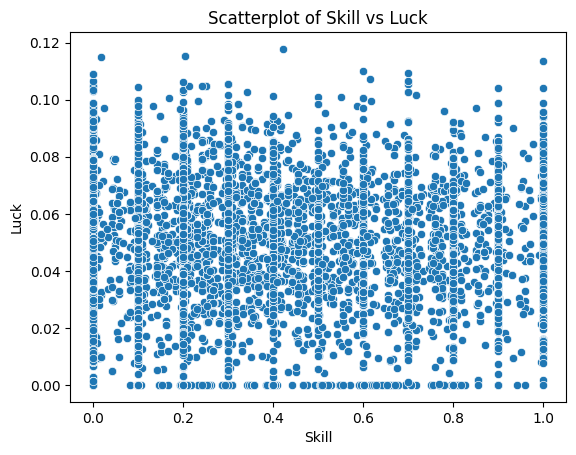

In [69]:
sns.scatterplot(data=data_5, x='Skill', y='Luck')
plt.title('Scatterplot of Skill vs Luck')
plt.show()

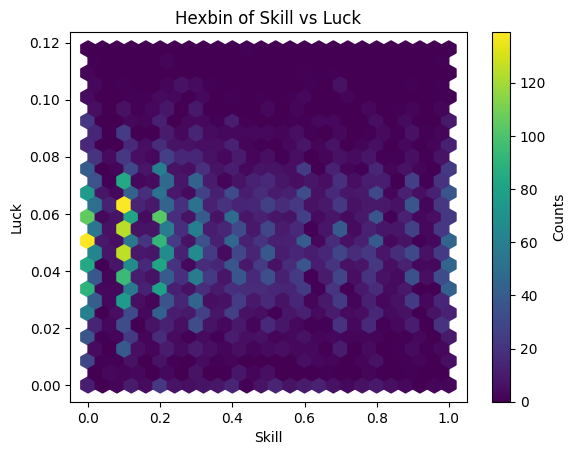

In [71]:
plt.hexbin(df['Skill'], df['Luck'], gridsize=25, cmap='viridis')
plt.colorbar(label='Counts')
plt.xlabel('Skill')
plt.ylabel('Luck')
plt.title('Hexbin of Skill vs Luck')
plt.show()

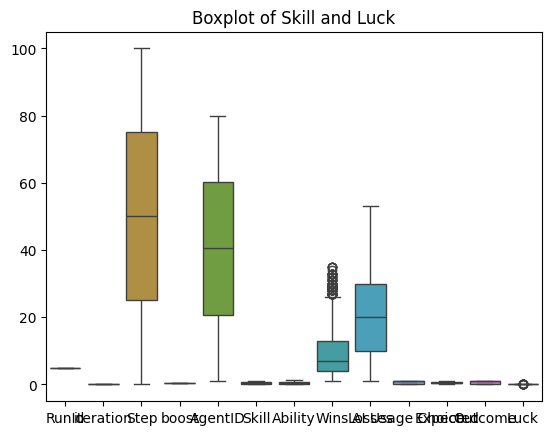

In [72]:
sns.boxplot(data=df)
plt.title('Boxplot of Skill and Luck')
plt.show()

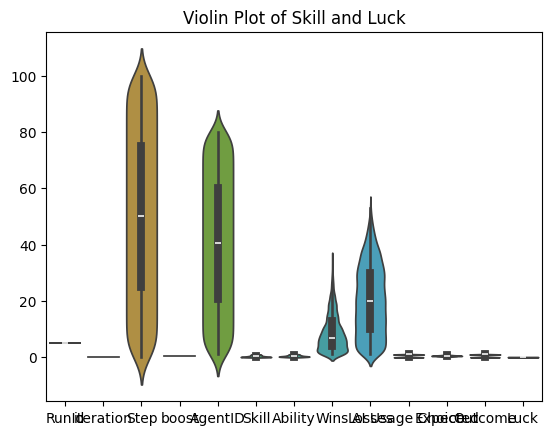

In [73]:
sns.violinplot(data=df)
plt.title('Violin Plot of Skill and Luck')
plt.show()

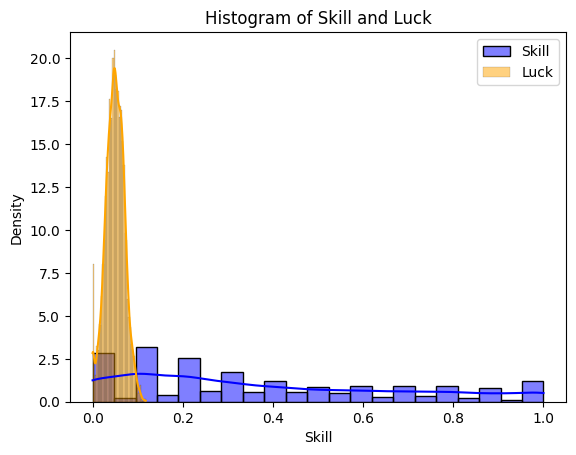

In [74]:
sns.histplot(df['Skill'], color='blue', label='Skill', kde=True, stat='density', alpha=0.5)
sns.histplot(df['Luck'], color='orange', label='Luck', kde=True, stat='density', alpha=0.5)
plt.legend()
plt.title('Histogram of Skill and Luck')
plt.show()

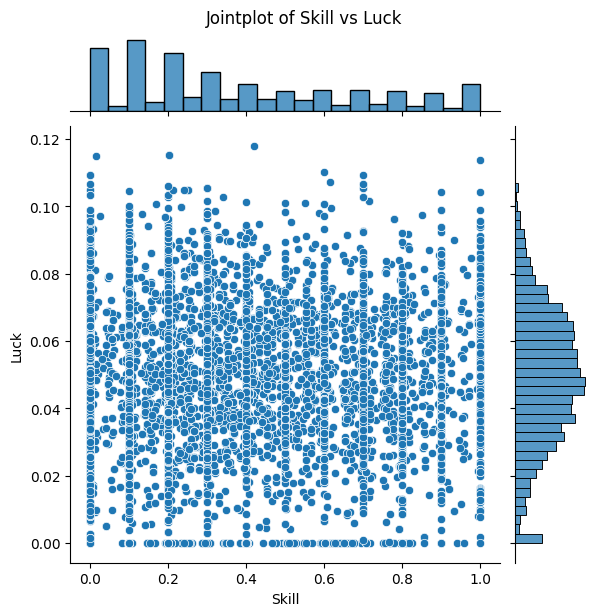

In [75]:
sns.jointplot(data=df, x='Skill', y='Luck', kind='scatter')
plt.suptitle('Jointplot of Skill vs Luck', y=1.02)
plt.show()

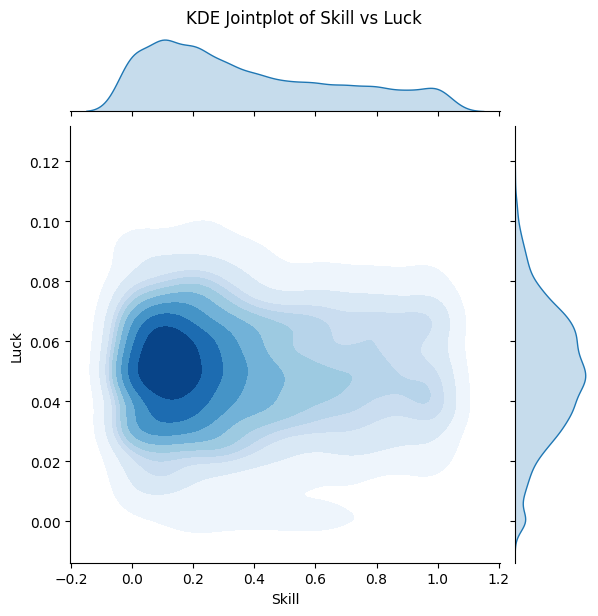

In [76]:
sns.jointplot(data=df, x='Skill', y='Luck', kind='kde', fill=True, cmap='Blues')
plt.suptitle('KDE Jointplot of Skill vs Luck', y=1.02)
plt.show()

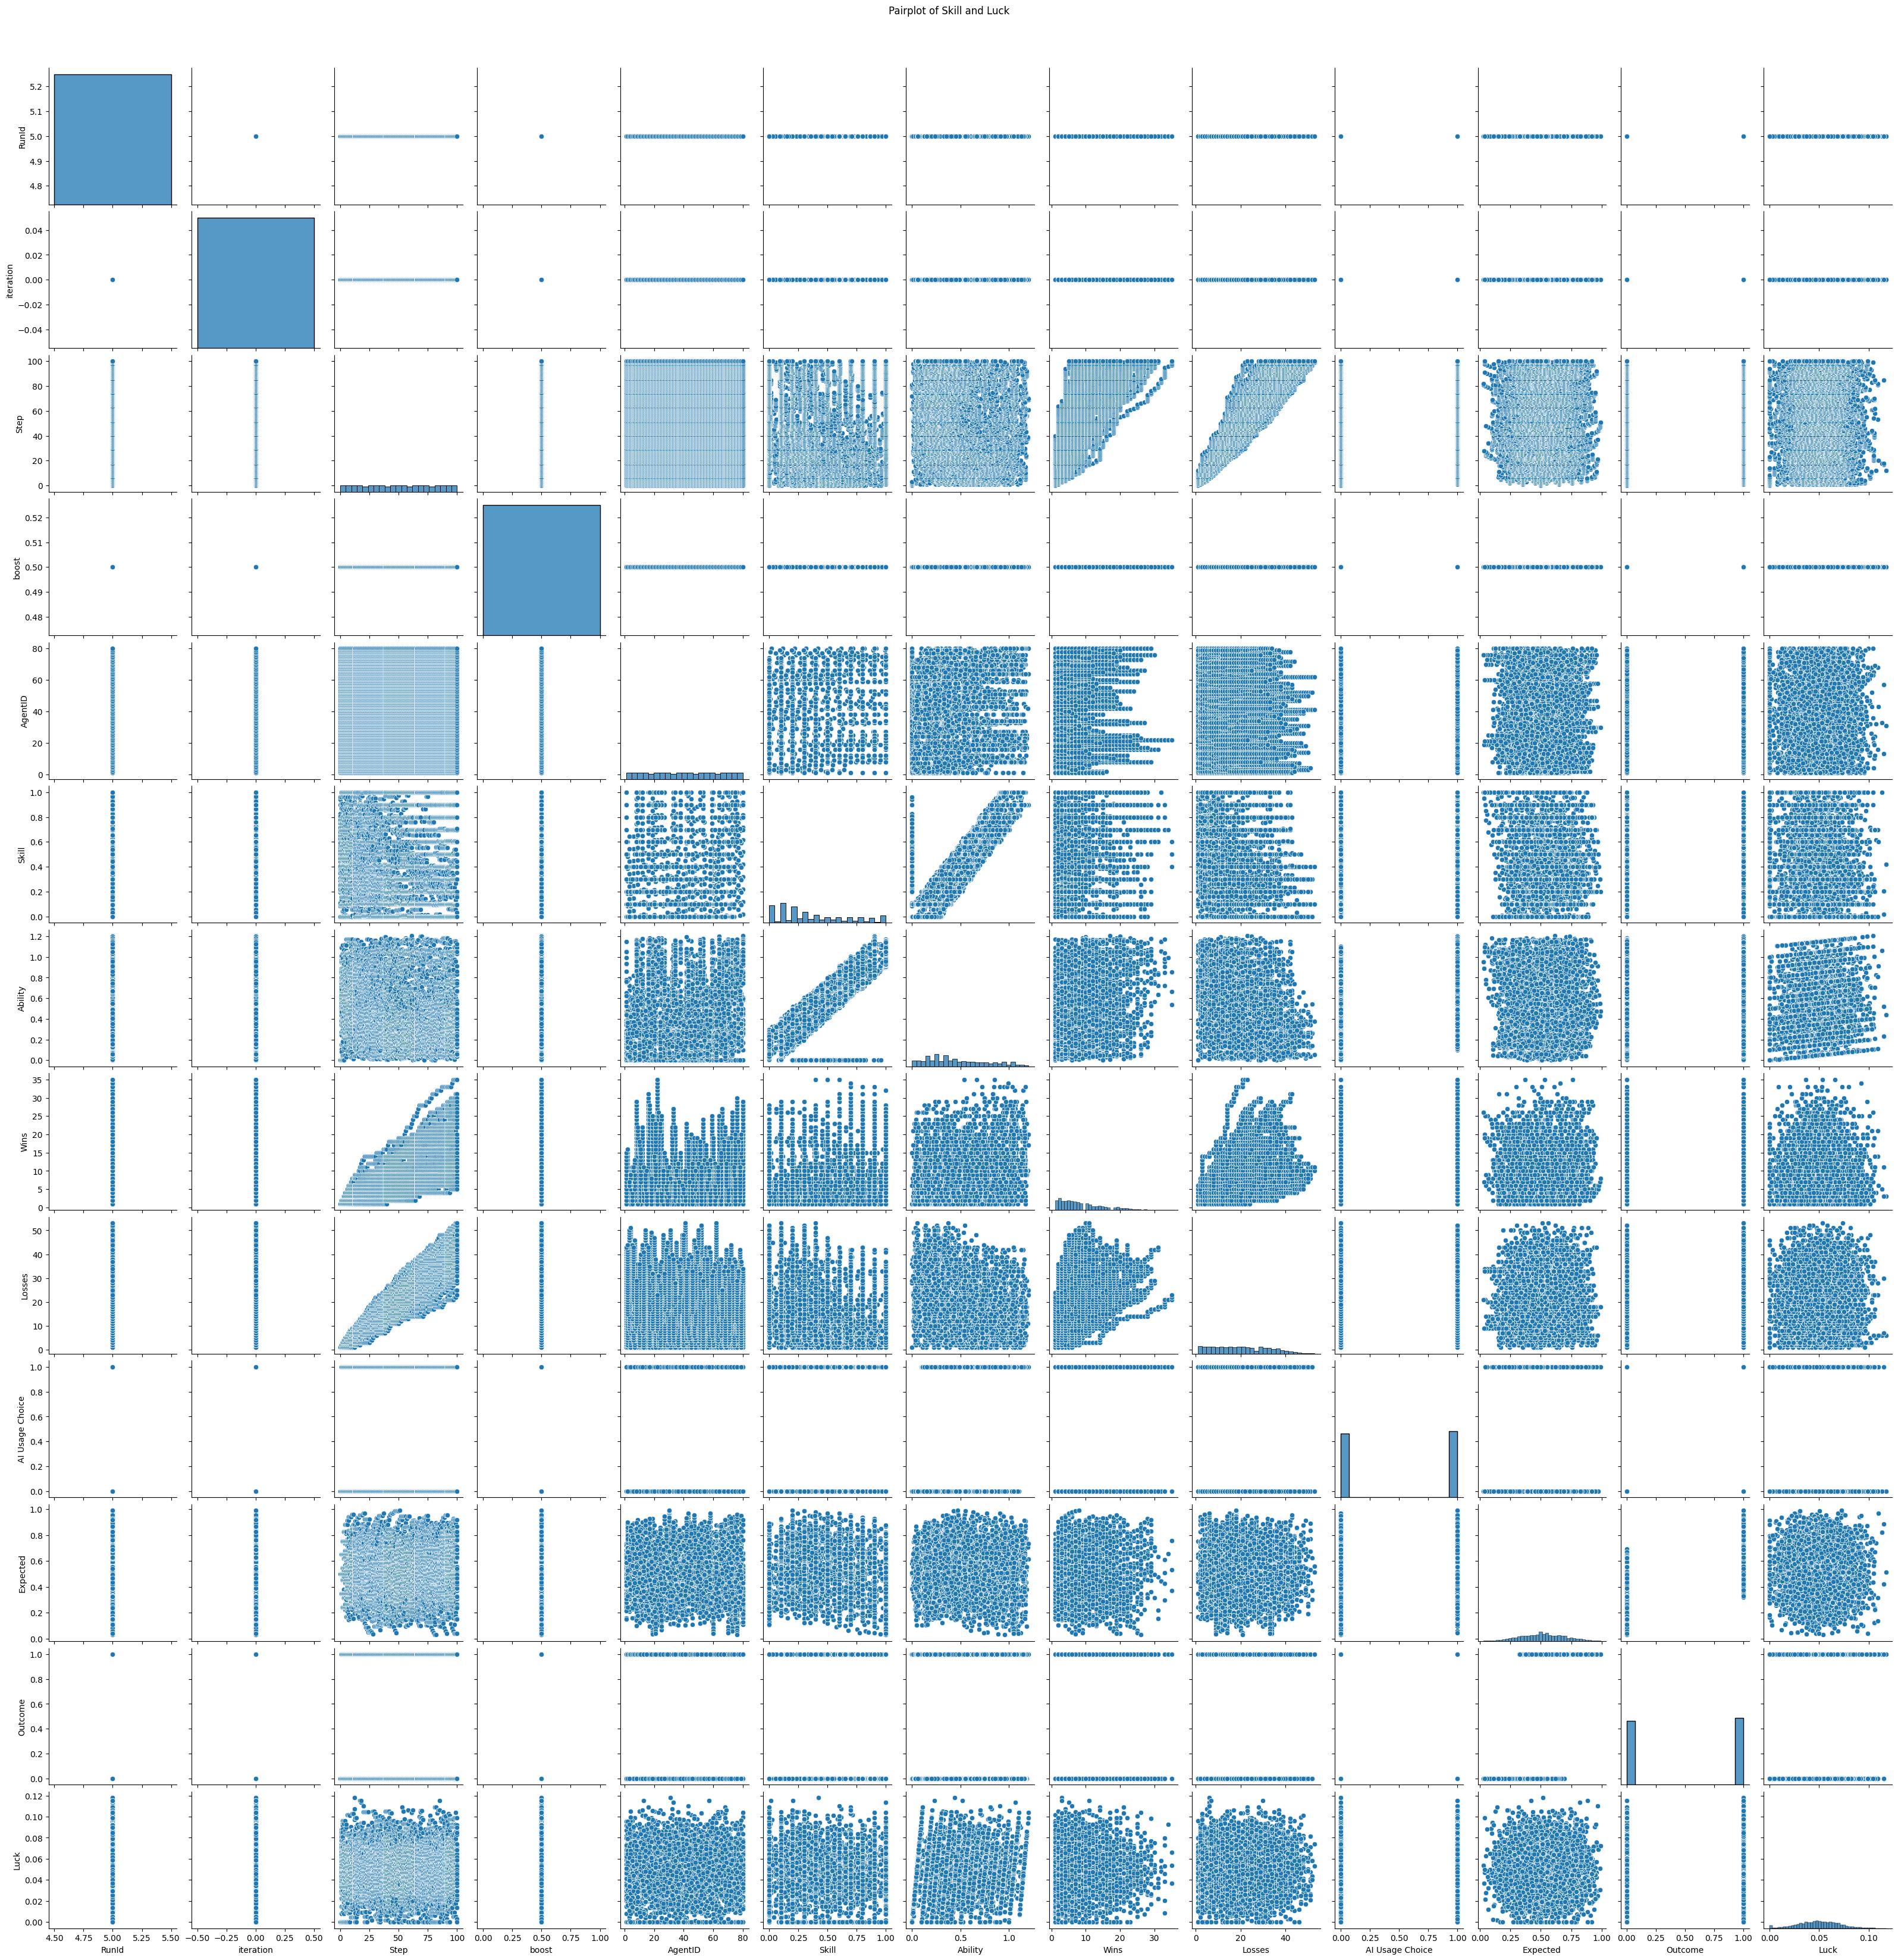

In [77]:
sns.pairplot(df)
plt.suptitle('Pairplot of Skill and Luck', y=1.02)
plt.show()

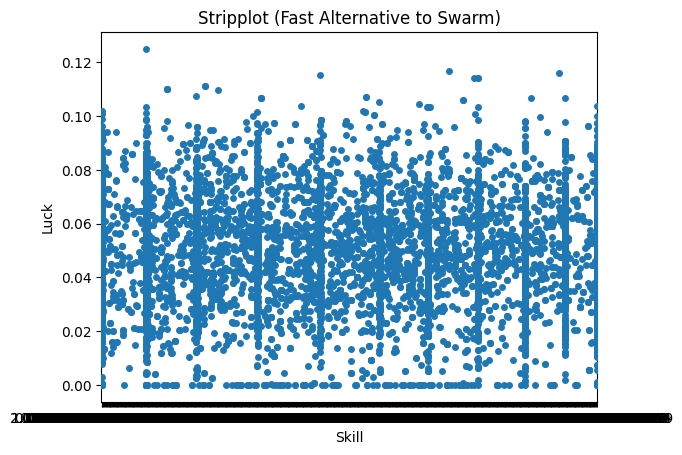

In [10]:
sns.stripplot(data=data_5, x='Skill', y='Luck', jitter=True)
plt.title('Stripplot (Fast Alternative to Swarm)')
plt.show()


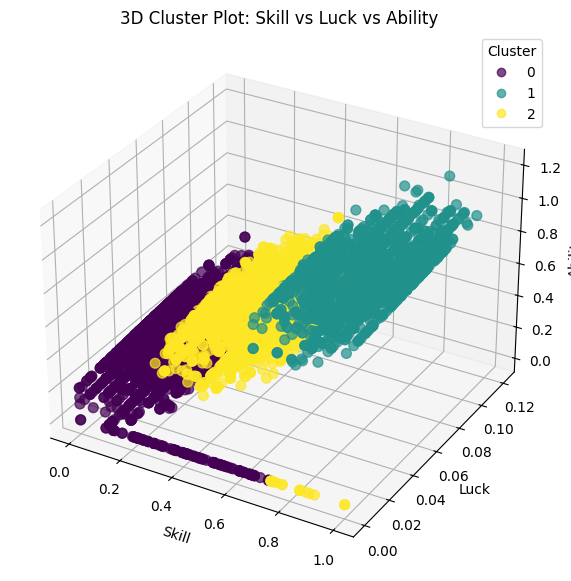

In [12]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
import numpy as np

# Pick your features
df = data_3[['Skill', 'Luck', 'Ability']].dropna()

# Fit KMeans (choose k=3 or whatever)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df)

# 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['Skill'], df['Luck'], df['Ability'],
                     c=df['Cluster'], cmap='viridis', s=50, alpha=0.7)

ax.set_xlabel('Skill')
ax.set_ylabel('Luck')
ax.set_zlabel('Ability')
ax.set_title('3D Cluster Plot: Skill vs Luck vs Ability')
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()